In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!git clone https://github.com/shubhamkovhal01/Cardiac-Segmentation.git
%cd Cardiac-Segmentation
!git config pull.rebase false
!git config user.email "shubhamkovhal@gmail.com"
!git config user.name "Shubhamkovhal01"

Cloning into 'Cardiac-Segmentation'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 24 (delta 4), reused 19 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (24/24), 7.39 KiB | 7.39 MiB/s, done.
Resolving deltas: 100% (4/4), done.
/content/Cardiac-Segmentation


In [3]:
!pip install monai nibabel matplotlib numpy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 61.4 MB/s eta 0:00:00


In [4]:
from monai.apps import DecathlonDataset

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


In [5]:
from pathlib import Path

In [6]:
root_dir=Path("/content/drive/MyDrive/Cardiac-Segmentation/data")
root_dir.mkdir(parents=True,exist_ok=True)

In [7]:
dataset=DecathlonDataset(
    root_dir=root_dir,
    task="Task02_Heart",
    section="training",
    download=True
)



2026-06-19 23:38:43,521 - INFO - Verified 'Task02_Heart.tar', md5: 06ee59366e1e5124267b774dbd654057.
2026-06-19 23:38:43,522 - INFO - File exists: /content/drive/MyDrive/Cardiac-Segmentation/data/Task02_Heart.tar, skipped downloading.
2026-06-19 23:38:43,796 - INFO - Non-empty folder exists in /content/drive/MyDrive/Cardiac-Segmentation/data/Task02_Heart, skipped extracting.


Loading dataset: 100%|██████████| 16/16 [00:31<00:00,  1.97s/it]


In [8]:
import os
images=os.listdir("/content/drive/MyDrive/Cardiac-Segmentation/data/Task02_Heart/imagesTr")
labels=os.listdir("/content/drive/MyDrive/Cardiac-Segmentation/data/Task02_Heart/labelsTr")
print(f"Number of images: {len(images)}")
print(f"Number of labels: {len(labels)}")

Number of images: 21
Number of labels: 22


In [9]:
images=[image for image in images if not image.startswith(".") and not image.startswith("_")]
labels=[label for label in labels if not label.startswith(".") and not label.startswith("_")]

In [10]:
print(f"Number of images: {len(images)}")
print(f"Number of labels: {len(labels)}")

Number of images: 20
Number of labels: 20


In [11]:
image_set=set(images)
label_set=set(labels)
print(f"Perfectly paired: {image_set == label_set}")
print(f"Images missing labels: {image_set - label_set}")
print(f"Labels missing images: {label_set - image_set}")

Perfectly paired: True
Images missing labels: set()
Labels missing images: set()


In [12]:
import nibabel as nib
import numpy as np

img_path="/content/drive/MyDrive/Cardiac-Segmentation/data/Task02_Heart/imagesTr/"+images[0]
label_path="/content/drive/MyDrive/Cardiac-Segmentation/data/Task02_Heart/labelsTr/"+labels[0]

img=nib.load(img_path)
label=nib.load(label_path)

img_data=img.get_fdata()
label_data=label.get_fdata()

print(f"Image shape: {img_data.shape}")
print(f"Label shape: {label_data.shape}")
print(f"Voxel spacing: {img.header.get_zooms()}")
print(f"Intensity range: {img_data.max()} to {img_data.min()}")
print(f"Label values: {np.unique(label_data)}")

Image shape: (320, 320, 130)
Label shape: (320, 320, 130)
Voxel spacing: (np.float32(1.25), np.float32(1.25), np.float32(1.37))
Intensity range: 1873.0 to 0.0
Label values: [0. 1.]


In [13]:
for fname in images:
    img_path = "/content/drive/MyDrive/Cardiac-Segmentation/data/Task02_Heart/imagesTr/" + fname
    nib_img = nib.load(img_path)
    data = nib_img.get_fdata()
    spacing = nib_img.header.get_zooms()
    shape = data.shape
    print(f"{fname} | shape: {shape} | spacing: {spacing} | range: {data.min():.0f}–{data.max():.0f}")

la_007.nii.gz | shape: (320, 320, 130) | spacing: (np.float32(1.25), np.float32(1.25), np.float32(1.37)) | range: 0–1873
la_019.nii.gz | shape: (320, 320, 100) | spacing: (np.float32(1.25), np.float32(1.25), np.float32(1.37)) | range: 0–1662
la_023.nii.gz | shape: (320, 320, 110) | spacing: (np.float32(1.25), np.float32(1.25), np.float32(1.37)) | range: 0–1999
la_005.nii.gz | shape: (320, 320, 120) | spacing: (np.float32(1.25), np.float32(1.25), np.float32(1.37)) | range: 0–1888
la_009.nii.gz | shape: (320, 320, 100) | spacing: (np.float32(1.25), np.float32(1.25), np.float32(1.37)) | range: 0–2171
la_017.nii.gz | shape: (320, 320, 120) | spacing: (np.float32(1.25), np.float32(1.25), np.float32(1.37)) | range: 0–1937
la_021.nii.gz | shape: (320, 320, 100) | spacing: (np.float32(1.25), np.float32(1.25), np.float32(1.37)) | range: 0–1852
la_029.nii.gz | shape: (320, 320, 109) | spacing: (np.float32(1.25), np.float32(1.25), np.float32(1.37)) | range: 0–2196
la_003.nii.gz | shape: (320, 320

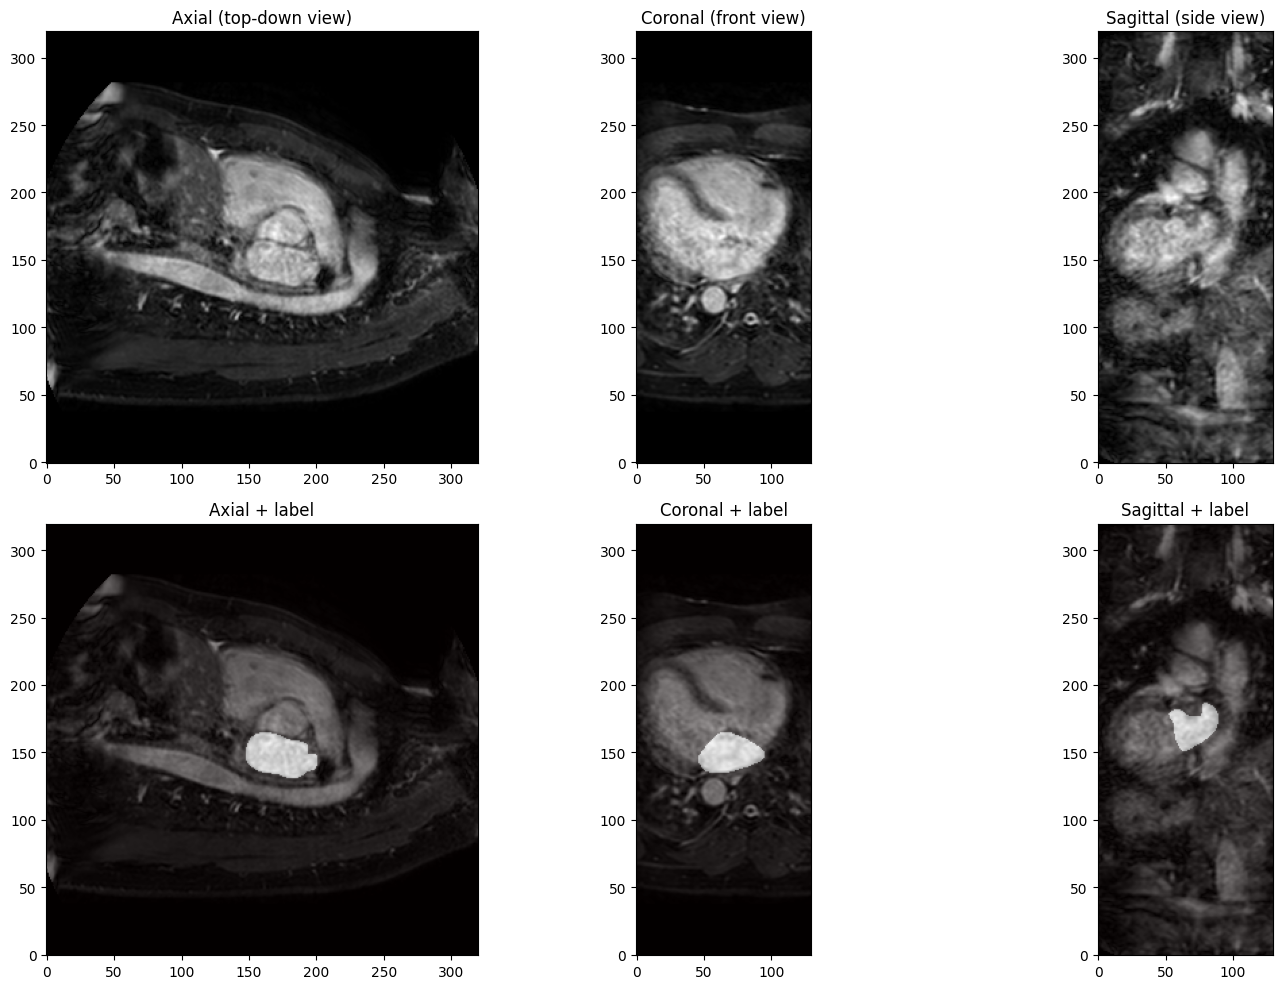

In [14]:
import matplotlib.pyplot as plt

# middle slice indices
x_mid = img_data.shape[0] // 2  # 160
y_mid = img_data.shape[1] // 2  # 160
z_mid = img_data.shape[2] // 2  # 65

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# --- ROW 1: raw MRI ---
axes[0, 0].imshow(img_data[:, :, z_mid], cmap='gray', origin='lower')
axes[0, 0].set_title('Axial (top-down view)')

axes[0, 1].imshow(img_data[:, y_mid, :], cmap='gray', origin='lower')
axes[0, 1].set_title('Coronal (front view)')

axes[0, 2].imshow(img_data[x_mid, :, :], cmap='gray', origin='lower')
axes[0, 2].set_title('Sagittal (side view)')

# --- ROW 2: MRI + label overlay ---
axes[1, 0].imshow(img_data[:, :, z_mid], cmap='gray', origin='lower')
axes[1, 0].imshow(label_data[:, :, z_mid], cmap='hot', alpha=0.4, origin='lower')
axes[1, 0].set_title('Axial + label')

axes[1, 1].imshow(img_data[:, y_mid, :], cmap='gray', origin='lower')
axes[1, 1].imshow(label_data[:, y_mid, :], cmap='hot', alpha=0.4, origin='lower')
axes[1, 1].set_title('Coronal + label')

axes[1, 2].imshow(img_data[x_mid, :, :], cmap='gray', origin='lower')
axes[1, 2].imshow(label_data[x_mid, :, :], cmap='hot', alpha=0.4, origin='lower')
axes[1, 2].set_title('Sagittal + label')

plt.tight_layout()
plt.show()

# Phase2 : Transform

In [15]:
# TASK: Import everything needed for Phase 2 transforms
# WHY: MONAI transform classes handle all preprocessing steps

from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Spacingd,
    Orientationd,
    ScaleIntensityRangePercentilesd,
    CropForegroundd,
    RandCropByPosNegLabeld,
    RandAffined,
    RandGaussianNoised,
    RandFlipd,
)
from monai.data import DataLoader, Dataset, CacheDataset

In [16]:
# TASK: Build data_dicts — list of {"image": path, "label": path} for all 20 volumes
# WHY: MONAI dictionary transforms expect this exact format
# HINT: Use your clean `images` and `labels` lists from Phase 1
#       combine with data_dir to make full paths

data_dir = Path("/content/drive/MyDrive/Cardiac-Segmentation/data/Task02_Heart")

data_dicts = [
    {"image": data_dir / "imagesTr" / img_name,
     "label": data_dir / "labelsTr" / lbl_name}
    for img_name, lbl_name in zip(images, labels)
]

print(f"Total samples: {len(data_dicts)}")
print(f"First entry: {data_dicts[0]}")

Total samples: 20
First entry: {'image': PosixPath('/content/drive/MyDrive/Cardiac-Segmentation/data/Task02_Heart/imagesTr/la_007.nii.gz'), 'label': PosixPath('/content/drive/MyDrive/Cardiac-Segmentation/data/Task02_Heart/labelsTr/la_007.nii.gz')}


In [17]:
# TASK: Split data_dicts into train and val sets
# WHY: Need separate sets — train for learning, val for honest evaluation
# HINT: Python list slicing — first 16 for train, last 4 for val

import random
random.seed(42)
random.shuffle(data_dicts)

train_files = data_dicts[:16]
val_files = data_dicts[16:]

print(f"Train:{len(train_files)}, Val:{len(val_files)}")

Train:16, Val:4


In [29]:
# TASK: Build the shared transform chain (applied to both train and val)
# WHY: These make data consistent and model-ready
# LOOK AT: https://docs.monai.io/en/stable/transforms.html
# HINT: All transform names end in 'd' because they operate on dicts

shared_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Spacingd(
        keys=["image", "label"],
        pixdim=(1.5, 1.5, 1.5),
        mode=("bilinear", "nearest")  # why different modes? think about it
    ),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    ScaleIntensityRangePercentilesd(
        keys=["image"],
        lower=0.5,
        upper=99.5,
        b_min=0.0,
        b_max=1.0,
        clip=True
    ),
])

In [39]:
# TASK: Build train-specific transforms (augmentation + patch sampling)
# WHY: Artificially expand 16 volumes, prevent overfitting
# LOOK AT: https://docs.monai.io/en/stable/transforms.html#intensity-transforms

train_transforms = Compose([
    shared_transforms,
    RandAffined(
        keys=["image", "label"],
        mode=("bilinear", "nearest"),
        prob=0.5,
        rotate_range=(0.35, 0.35, 0.35),
        scale_range=(0.1, 0.1, 0.1),
    ),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
    RandGaussianNoised(keys=["image"], prob=0.2, mean=0.0, std=0.1),
    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=(128, 128, 80),
        pos=1,
        neg=1,
        num_samples=2,
    ),
])

val_transforms = Compose([
    shared_transforms,
])

In [40]:
# TASK: Create Dataset and DataLoader for train and val
# WHY: Dataset applies transforms lazily, DataLoader batches and shuffles
# LOOK AT: https://docs.monai.io/en/stable/data.html#monai.data.CacheDataset
# HINT: Use CacheDataset not Dataset — it caches transformed results in RAM
#       cache_rate=1.0 means cache everything (fine for 16 volumes)

from monai.data import pad_list_data_collate
train_ds = CacheDataset(
    data=train_files,
    transform=train_transforms,
    cache_rate=1.0,
)

val_ds = CacheDataset(
    data=val_files,
    transform=val_transforms,
    cache_rate=1.0,
)

train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, collate_fn=pad_list_data_collate,)
val_loader = DataLoader(val_ds, batch_size=2, shuffle=False, collate_fn=pad_list_data_collate,)

Loading dataset: 100%|██████████| 4/4 [00:00<00:00, 46863.73it/s]


In [42]:
# TASK: Pull one batch and inspect its shape
# WHY: This tells us if patches were actually extracted and transformed correctly

batch = next(iter(train_loader))
print(batch["image"].shape)
print(batch["label"].shape)
print(batch["image"].min(), batch["image"].max())
print(batch["label"].unique())

torch.Size([4, 1, 128, 128, 80])
torch.Size([4, 1, 128, 128, 80])
metatensor(0.) metatensor(1.)
metatensor([0., 1.])


In [24]:
import getpass
token = getpass.getpass("Paste token: ")

# Save current notebook to Drive first, THEN push
import shutil

shutil.copy("/content/drive/MyDrive/Colab Notebooks/Medical Segmentation Decathlon.ipynb",
            "/content/Cardiac-Segmentation/notebooks/cardiac_segmentation.ipynb")
!git pull --no-edit https://{token}@github.com/shubhamkovhal01/Cardiac-Segmentation.git
!git add .
!git commit -m "add: data visualisation"
!git push https://{token}@github.com/shubhamkovhal01/Cardiac-Segmentation.git